# Testes de Hipótese — Comparação Estatística de Modelos

## Objetivo

Neste notebook, usamos **testes de hipótese** para decidir qual modelo colocar em produção.
As perguntas que guiam a análise:

1. **Existe diferença global entre os modelos?** — Friedman test
2. **Quais pares são realmente diferentes?** — Nemenyi post-hoc
3. **O melhor RF vs o melhor MLP — qual é superior?** — Comparação focada
4. **Qual modelo escolher?** — Decisão com parcimônia

## Por que precisamos de testes de hipótese?

Quando treinamos modelos com K-Fold CV, obtemos **múltiplas medições** de desempenho.
A pergunta "Modelo A é melhor que B?" não pode ser respondida apenas comparando médias —
precisamos verificar se a diferença é **estatisticamente significativa** ou se pode ser
explicada pela **variabilidade natural** dos dados.

> **Nota:** Toda esta análise é **avaliação offline** (dados históricos + K-Fold).
> Na indústria, ela serve como **triagem** antes de um A/B test em produção.

In [12]:
import sys
sys.path.insert(0, "..")

import mlflow
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import scikit_posthocs as sp
from scipy import stats
from src.config import MLFLOW_TRACKING_URI, EXPERIMENT_NAME, PRIMARY_METRIC, METRICS, N_FOLDS

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
client = mlflow.tracking.MlflowClient()

ALPHA = 0.05

print(f"\u2713 Conectado ao MLflow: {MLFLOW_TRACKING_URI}")
print(f"  Experimento: {EXPERIMENT_NAME}")
print(f"  Métrica primária: {PRIMARY_METRIC}")
print(f"  Nível de significância (\u03b1): {ALPHA}")

✓ Conectado ao MLflow: http://localhost:5001
  Experimento: teste-hipotese-credit-default
  Métrica primária: roc_auc
  Nível de significância (α): 0.05


## 1. Recuperar Resultados do MLflow

Durante o treino (`make train-all`), cada configuração gerou um **run** no MLflow com:
- **Parâmetros** do grid search
- **Métricas por fold** (logadas com `step=fold_idx`)
- **Modelo** serializado como artifact

Vamos buscar todos os parent runs e carregar os scores de cada fold.

In [13]:
# Buscar parent runs (converter pandas -> polars)
runs_pd = mlflow.search_runs(experiment_names=[EXPERIMENT_NAME], filter_string=f"params.n_folds = '{N_FOLDS}'")
runs = pl.from_pandas(runs_pd)

# Filtrar parent runs
parent_runs = runs.filter(pl.col("params.model_type").is_not_null())
parent_runs = parent_runs.sort(f"metrics.mean_{PRIMARY_METRIC}", descending=True)

# Adicionar run_name a partir das tags
parent_runs = parent_runs.with_columns(
    pl.col("tags.mlflow.runName").alias("run_name")
)

print(f"Configurações encontradas: {parent_runs.height}\n")
parent_runs.select(["run_name", f"metrics.mean_{PRIMARY_METRIC}", f"metrics.std_{PRIMARY_METRIC}", "params.model_type"])

Configurações encontradas: 9



run_name,metrics.mean_roc_auc,metrics.std_roc_auc,params.model_type
str,f64,f64,str
"""mlp_config_2""",0.781005,0.009726,"""mlp_config_2"""
"""mlp_config_0""",0.780744,0.009031,"""mlp_config_0"""
"""mlp_config_1""",0.779844,0.009948,"""mlp_config_1"""
"""random_forest_config_1""",0.778737,0.009154,"""random_forest_config_1"""
"""random_forest_config_0""",0.773513,0.007952,"""random_forest_config_0"""
"""random_forest_config_2""",0.77259,0.010571,"""random_forest_config_2"""
"""logistic_regression_config_1""",0.723655,0.012833,"""logistic_regression_config_1"""
"""logistic_regression_config_2""",0.723645,0.01283,"""logistic_regression_config_2"""
"""logistic_regression_config_0""",0.723615,0.012851,"""logistic_regression_config_0"""


In [14]:
def load_scores(run_id, metric=PRIMARY_METRIC):
    """Carrega fold scores de um run via MLflow metric history."""
    history = client.get_metric_history(run_id, metric)
    values = sorted(history, key=lambda m: m.step)
    return np.array([m.value for m in values if m.step < N_FOLDS])

# Construir dicionário de scores e mapeamento run_id
all_scores = {}
run_ids = {}
for row in parent_runs.iter_rows(named=True):
    name = row["run_name"]
    all_scores[name] = load_scores(row["run_id"])
    run_ids[name] = row["run_id"]

# Verificar
first = list(all_scores.keys())[0]
print(f"Exemplo: {first} \u2192 {len(all_scores[first])} folds")
print(f"Scores: {all_scores[first].round(4)}")

Exemplo: mlp_config_2 → 10 folds
Scores: [0.7828 0.8047 0.7713 0.7809 0.7661 0.7871 0.7795 0.7766 0.7787 0.7824]


## 2. Visão Global: Friedman Test

Com 9 modelos (3 RF + 3 LR + 3 MLP), o primeiro passo é verificar se **existe alguma
diferença** entre eles. Não faz sentido comparar pares se todos forem equivalentes.

O **teste de Friedman** é o equivalente não-paramétrico da ANOVA de medidas repetidas:
- **$H_0$**: Todos os modelos têm desempenho equivalente
- **$H_a$**: Pelo menos um modelo difere dos demais

Se rejeitarmos $H_0$, sabemos que *algo* é diferente, mas não *o quê*.

In [15]:
# Friedman test com todos os modelos
model_names = sorted(all_scores.keys())
arrays = [all_scores[n] for n in model_names]
stat_f, p_f = stats.friedmanchisquare(*arrays)

print(f"Friedman chi\u00b2 = {stat_f:.4f}")
print(f"p-valor = {p_f:.6f}")
print()

if p_f < ALPHA:
    print(f"\u2713 SIGNIFICATIVO (p={p_f:.6f} < {ALPHA})")
    print("  Pelo menos um par de modelos difere. Prosseguimos com post-hoc.")
else:
    print(f"\u2717 NÃO SIGNIFICATIVO (p={p_f:.6f} \u2265 {ALPHA})")
    print("  Sem evidência de diferença global entre os modelos.")

Friedman chi² = 70.8533
p-valor = 0.000000

✓ SIGNIFICATIVO (p=0.000000 < 0.05)
  Pelo menos um par de modelos difere. Prosseguimos com post-hoc.


## 3. Quais Pares Diferem? Nemenyi Post-hoc

O Friedman nos disse que *algo* é diferente. Agora precisamos saber **onde** estão as
diferenças. O **post-hoc de Nemenyi** testa todos os pares simultaneamente.

Ponto crucial: com 9 modelos temos **C(9,2) = 36 pares**. O Nemenyi **corrige para
comparações múltiplas**, o que significa que o limiar para declarar significância é
**mais exigente** do que um simples t-test entre dois modelos. Isso é intencional —
sem correção, a chance de pelo menos um falso positivo em 36 testes seria ~84%.

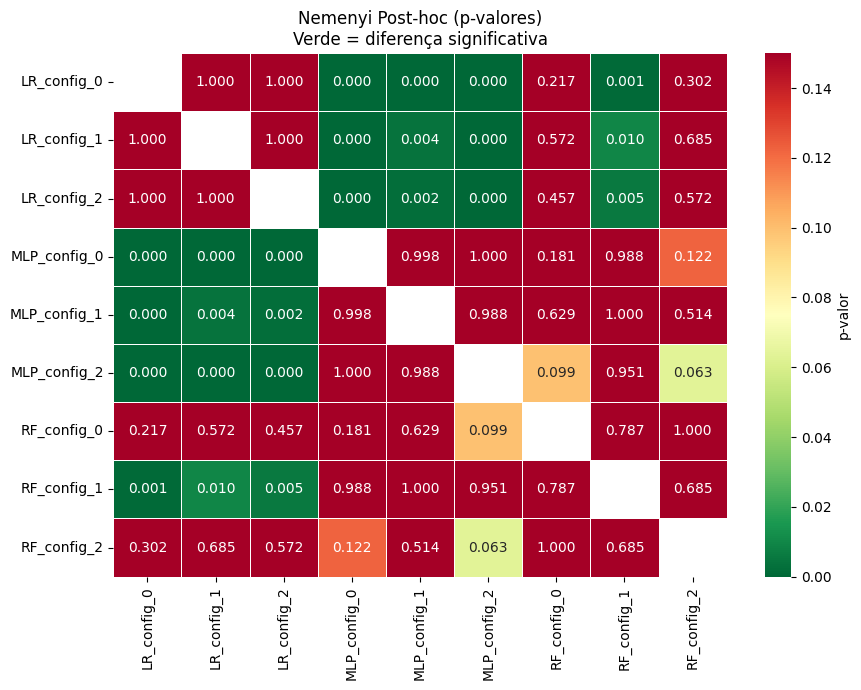

Pares com diferença significativa (Nemenyi, p < 0.05):
  • LR_config_0 vs MLP_config_0: p=0.0000
  • LR_config_0 vs MLP_config_1: p=0.0004
  • LR_config_0 vs MLP_config_2: p=0.0000
  • LR_config_0 vs RF_config_1: p=0.0010
  • LR_config_1 vs MLP_config_0: p=0.0002
  • LR_config_1 vs MLP_config_1: p=0.0040
  • LR_config_1 vs MLP_config_2: p=0.0001
  • LR_config_1 vs RF_config_1: p=0.0099
  • LR_config_2 vs MLP_config_0: p=0.0001
  • LR_config_2 vs MLP_config_1: p=0.0021
  • LR_config_2 vs MLP_config_2: p=0.0000
  • LR_config_2 vs RF_config_1: p=0.0054


In [17]:
# Nemenyi post-hoc
data_matrix = np.column_stack(arrays)
nemenyi = sp.posthoc_nemenyi_friedman(data_matrix)

short_names = [
    n.replace("random_forest_", "RF_").replace("logistic_regression_", "LR_").replace("mlp_", "MLP_")
    for n in model_names
]
nemenyi.index = short_names
nemenyi.columns = short_names

# Heatmap
fig, ax = plt.subplots(figsize=(9, 7))
mask = np.eye(len(short_names), dtype=bool)
sns.heatmap(nemenyi, annot=True, fmt=".3f", cmap="RdYlGn_r",
            vmin=0, vmax=0.15, ax=ax, linewidths=0.5, mask=mask,
            cbar_kws={"label": "p-valor"})
ax.set_title("Nemenyi Post-hoc (p-valores)\nVerde = diferença significativa")
plt.tight_layout()
plt.show()

# Pares significativos
print("Pares com diferença significativa (Nemenyi, p < 0.05):")
sig_count = 0
for i in range(len(model_names)):
    for j in range(i + 1, len(model_names)):
        p = nemenyi.iloc[i, j]
        if p < ALPHA:
            sig_count += 1
            print(f"  \u2022 {short_names[i]} vs {short_names[j]}: p={p:.4f}")
if sig_count == 0:
    print("  Nenhum par significativo pelo Nemenyi.")

Padrões observados:
1. LR vs MLP: todas as Logísticas são significativamente piores que todos os MLPs
2. LR vs RF: resultados mistos
3. MLP vs RF: diferenças sutis — Nemenyi pode não considerar significativas
4. Dentro de cada família: configs são estatisticamente equivalentes entre si

### Lição: Não Polua a Comparação

Com 9 modelos, o Nemenyi corrige para **36 pares** — um limiar muito exigente.
Cada modelo extra que você adiciona "encarece" a evidência necessária para TODOS os pares.

Se as 3 configurações de LR foram incluídas apenas como baseline, elas estão
**dificultando** a detecção de diferenças entre MLP e RF. Na prática:

- **9 modelos**: 36 pares - correção severa
- **6 modelos** (sem LR): 15 pares - correção mais leve
- **2 modelos** (RF vs MLP): 1 par - sem correção necessária

**Regra prática:** inclua na análise global apenas os modelos que são candidatos reais.
Use o Nemenyi para a triagem ampla, e depois faça uma **comparação focada** (um único
teste pareado) entre os finalistas.

Comparação SEM as Logísticas (6 modelos, 15 pares):

Friedman chi² = 35.3714, p = 0.000001


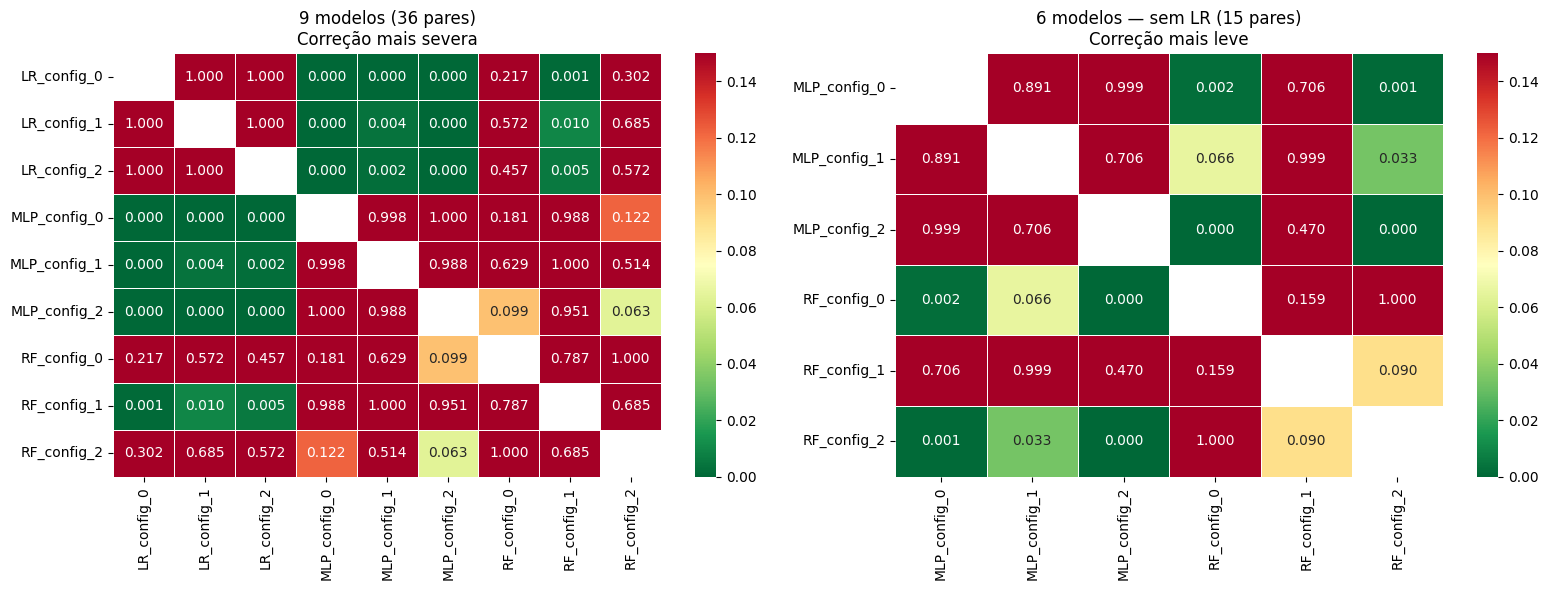

In [19]:
# Exercício: Impacto de modelos extras na correção do Nemenyi
print("Comparação SEM as Logísticas (6 modelos, 15 pares):\n")
rf_mlp_names = [n for n in model_names if not n.startswith("logistic")]
rf_mlp_arrays = [all_scores[n] for n in rf_mlp_names]

stat_f2, p_f2 = stats.friedmanchisquare(*rf_mlp_arrays)
print(f"Friedman chi² = {stat_f2:.4f}, p = {p_f2:.6f}")

data_matrix_2 = np.column_stack(rf_mlp_arrays)
nemenyi_2 = sp.posthoc_nemenyi_friedman(data_matrix_2)
short_2 = [n.replace("random_forest_", "RF_").replace("mlp_", "MLP_") for n in rf_mlp_names]
nemenyi_2.index = short_2
nemenyi_2.columns = short_2

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Esquerda: todos os 9 modelos
mask1 = np.eye(len(short_names), dtype=bool)
sns.heatmap(nemenyi, annot=True, fmt=".3f", cmap="RdYlGn_r", vmin=0, vmax=0.15,
            ax=axes[0], linewidths=0.5, mask=mask1)
axes[0].set_title("9 modelos (36 pares)\nCorreção mais severa")

# Direita: apenas RF + MLP (6 modelos)
mask2 = np.eye(len(short_2), dtype=bool)
sns.heatmap(nemenyi_2, annot=True, fmt=".3f", cmap="RdYlGn_r", vmin=0, vmax=0.15,
            ax=axes[1], linewidths=0.5, mask=mask2)
axes[1].set_title("6 modelos — sem LR (15 pares)\nCorreção mais leve")

plt.tight_layout()
plt.show()

Observe: pares RF vs MLP que eram 'não significativos' com 9 modelos
podem se tornar significativos com 6, porque a correção é menos severa.
Cada modelo extra que você inclui 'encarece' a evidência para TODOS os pares.

## 4. Comparação Focada: RF vs MLP

O Nemenyi fez a triagem ampla. Agora fazemos uma **comparação direta** entre os dois
finalistas: o melhor RF e o melhor MLP.

**Por que isso é válido?** Porque estamos fazendo **uma única comparação pré-planejada**
(não 36 comparações exploratórias). Para um único teste, o paired t-test/Wilcoxon é
apropriado sem correção para comparações múltiplas.

### Seleção de representantes (parcimônia)

O Nemenyi confirmou que, dentro de cada família (RF, MLP), as configurações são
estatisticamente equivalentes. Logo, não precisamos usar a "melhor" config — usamos
a **mais simples** (config\_0). Isso é a **Navalha de Occam**: entre modelos equivalentes,
prefira o mais parcimonioso.

### Protocolo do teste pareado

```
Diferenças pareadas (d_i) → Shapiro-Wilk (normalidade) → Escolher teste → p-valor → Cohen's d → IC 95%
```

In [21]:
def run_hypothesis_test(scores_a, scores_b, name_a, name_b, metric=PRIMARY_METRIC, alpha=ALPHA):
    """Executa teste de hipótese completo entre dois conjuntos de scores pareados."""
    diff = scores_a - scores_b

    print(f"\n{'='*65}")
    print(f"  {name_a}  vs  {name_b}")
    print(f"  Métrica: {metric}")
    print(f"{'='*65}")
    print(f"\n  {name_a}: {np.mean(scores_a):.4f} \u00b1 {np.std(scores_a):.4f}")
    print(f"  {name_b}: {np.mean(scores_b):.4f} \u00b1 {np.std(scores_b):.4f}")
    print(f"  Diferença média: {np.mean(diff):+.4f} \u00b1 {np.std(diff):.4f}")

    # Shapiro-Wilk
    _, p_sw = stats.shapiro(diff)
    is_normal = p_sw >= alpha
    print(f"\n  [Shapiro-Wilk] p={p_sw:.4f} \u2192 {'Normal \u2713' if is_normal else 'Não normal \u2717'}")

    # Escolher teste
    if is_normal:
        stat, p_val = stats.ttest_rel(scores_a, scores_b)
        test_name = "Paired t-test"
    else:
        stat, p_val = stats.wilcoxon(scores_a, scores_b)
        test_name = "Wilcoxon signed-rank"

    print(f"  [{test_name}] statistic={stat:.4f}, p-value={p_val:.4f}")

    # Cohen's d
    std_diff = np.std(diff, ddof=1)
    d = np.mean(diff) / std_diff if std_diff > 0 else 0.0
    d_label = "negligível" if abs(d) < 0.2 else "pequeno" if abs(d) < 0.5 else "médio" if abs(d) < 0.8 else "grande"
    print(f"  [Cohen's d] d={d:.4f} (efeito {d_label})")

    # IC 95%
    se = stats.sem(diff)
    ci = stats.t.interval(0.95, df=len(diff)-1, loc=np.mean(diff), scale=se)
    print(f"  [IC 95%] [{ci[0]:.4f}, {ci[1]:.4f}]")

    # Conclusão
    print()
    if p_val < alpha:
        winner = name_a if np.mean(diff) > 0 else name_b
        print(f"  \u2713 SIGNIFICATIVO (p={p_val:.4f} < {alpha})")
        print(f"    \u2192 {winner} é estatisticamente superior.")
        if abs(d) < 0.2:
            print("    \u26a0 Porém o efeito é negligível — diferença pode não ser prática.")
    else:
        print("  \u2717 NÃO SIGNIFICATIVO (p={p_val:.4f} \u2265 {alpha})")
        print("    \u2192 Sem evidência de diferença. Prefira o modelo mais simples.")

    return {"test": test_name, "p_value": p_val, "cohens_d": d, "ci": ci, "significant": p_val < alpha, "mean_diff": np.mean(diff)}

In [22]:
# Selecionar representantes com parcimônia
# Dentro de cada família, configs são equivalentes (Nemenyi confirmou)
# Logo, usamos a config mais simples (config_0) — Navalha de Occam

rf_representative = "random_forest_config_0"
mlp_representative = "mlp_config_0"

print("Representantes selecionados (parcimônia — configs equivalentes dentro de cada família):")
print(f"  RF:  {rf_representative} (AUC={np.mean(all_scores[rf_representative]):.4f})")
print(f"  MLP: {mlp_representative} (AUC={np.mean(all_scores[mlp_representative]):.4f})")
print()

result_final = run_hypothesis_test(
    all_scores[rf_representative], all_scores[mlp_representative],
    rf_representative, mlp_representative
)

Representantes selecionados (parcimônia — configs equivalentes dentro de cada família):
  RF:  random_forest_config_0 (AUC=0.7735)
  MLP: mlp_config_0 (AUC=0.7807)


  random_forest_config_0  vs  mlp_config_0
  Métrica: roc_auc

  random_forest_config_0: 0.7735 ± 0.0080
  mlp_config_0: 0.7807 ± 0.0090
  Diferença média: -0.0072 ± 0.0036

  [Shapiro-Wilk] p=0.1475 → Normal ✓
  [Paired t-test] statistic=-6.0816, p-value=0.0002
  [Cohen's d] d=-1.9232 (efeito grande)
  [IC 95%] [-0.0099, -0.0045]

  ✓ SIGNIFICATIVO (p=0.0002 < 0.05)
    → mlp_config_0 é estatisticamente superior.


## 5. Interpretando Resultados Divergentes

### E se o t-test e o Nemenyi discordarem?

É comum que um paired t-test entre dois modelos específicos dê **significativo**, mas
o mesmo par apareça como **não significativo** no Nemenyi. Isso NÃO é um bug — são
perguntas diferentes:

| | Paired t-test | Nemenyi |
|---|---|---|
| **Pergunta** | "Esses 2 modelos específicos diferem?" | "Quais pares diferem entre TODOS os modelos?" |
| **Correção** | Nenhuma (1 comparação) | Corrige para todas as C(k,2) comparações |
| **Quando usar** | Comparação única, pré-planejada | Exploração entre múltiplos modelos |
| **Poder** | Maior (limiar mais baixo) | Menor (limiar mais alto) |

### Em qual confiar?

- Se você **planejou** comparar exatamente esses 2 modelos desde o início → **t-test**
- Se você está **explorando** entre vários modelos e testando muitos pares → **Nemenyi**
- Na dúvida, o Nemenyi é mais conservador (menos falsos positivos)

## 6. Visualizações

/var/folders/6x/3y02z1591rj130ytmr_hv8nh0000gn/T/ipykernel_23964/493466475.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(scores_list, labels=short_names, vert=True)


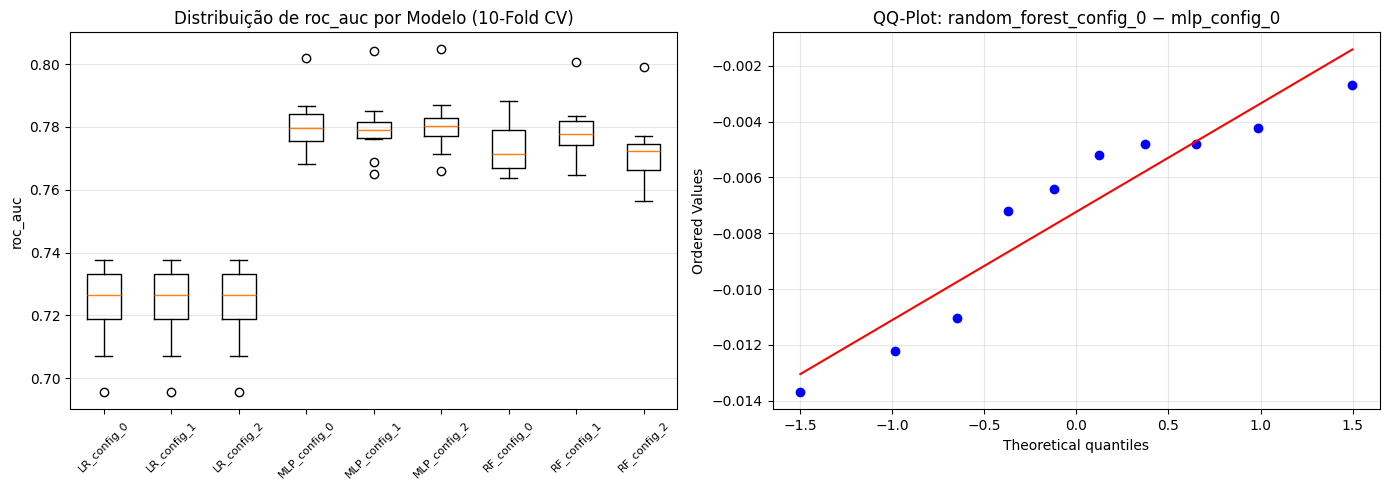

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
scores_list = [all_scores[n] for n in model_names]

axes[0].boxplot(scores_list, labels=short_names, vert=True)
axes[0].set_ylabel(PRIMARY_METRIC)
axes[0].set_title(f"Distribuição de {PRIMARY_METRIC} por Modelo (10-Fold CV)")
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].grid(axis='y', alpha=0.3)

# QQ-plot das diferenças RF vs MLP
diff_final = all_scores[rf_representative] - all_scores[mlp_representative]
stats.probplot(diff_final, dist="norm", plot=axes[1])
axes[1].set_title(f"QQ-Plot: {rf_representative} \u2212 {mlp_representative}")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Decisão Final

### Critério de Decisão

1. **Eliminar inferiores**: Nemenyi mostra que LR é significativamente pior → descartada
2. **Entre equivalentes, simplificar**: Configs dentro de RF e dentro de MLP não diferem → usar config\_0 (mais simples)
3. **Comparação focada**: RF config\_0 vs MLP config\_0
4. **Se significativo**: usar o vencedor
5. **Se não significativo**: preferir RF (mais simples, interpretável, sem GPU)

In [24]:
print("="*65)
print("  DECISÃO FINAL")
print("="*65)
print()
print(f"  Friedman test: p={p_f:.6f} \u2192 {'Significativo' if p_f < ALPHA else 'Não significativo'}")
print(f"  Nemenyi: LR eliminada (inferior); RF e MLP configs equivalentes dentro de cada família")
print()
print(f"  Comparação focada (teste pareado):")
print(f"    {rf_representative} vs {mlp_representative}")
print(f"    Teste: {result_final['test']}")
print(f"    p-valor: {result_final['p_value']:.4f}")
print(f"    Cohen's d: {result_final['cohens_d']:.4f}")
print(f"    IC 95%: [{result_final['ci'][0]:.4f}, {result_final['ci'][1]:.4f}]")
print()

if result_final["significant"]:
    if result_final["mean_diff"] > 0:
        champion = rf_representative
        reason = "estatisticamente superior"
    else:
        champion = mlp_representative
        reason = "estatisticamente superior"
else:
    champion = rf_representative
    reason = "sem diferença significativa — parcimônia (mais simples, interpretável, sem GPU)"

print(f"  \u2192 Champion: {champion}")
print(f"    Razão: {reason}")

  DECISÃO FINAL

  Friedman test: p=0.000000 → Significativo
  Nemenyi: LR eliminada (inferior); RF e MLP configs equivalentes dentro de cada família

  Comparação focada (teste pareado):
    random_forest_config_0 vs mlp_config_0
    Teste: Paired t-test
    p-valor: 0.0002
    Cohen's d: -1.9232
    IC 95%: [-0.0099, -0.0045]

  → Champion: mlp_config_0
    Razão: estatisticamente superior


### Critérios Práticos de Produção

Se RF e MLP empatam estatisticamente, os critérios de desempate são práticos:

| Critério | Random Forest | MLP |
|----------|--------------|-----|
| **Latência de inferência** | ~1ms | ~5-10ms |
| **Tamanho do modelo** | ~10-50MB | ~1-5MB |
| **Interpretabilidade** | Feature importance nativa | Black box (requer SHAP/LIME) |
| **Infraestrutura** | CPU | GPU recomendada para treino |
| **Monitoramento** | Fácil (distribuição de features) | Mais complexo (drift + performance) |
| **Manutenção** | Baixa | Requer retraining periódico |

> **Na prática:** Se não há diferença estatística, o RF é quase sempre a escolha certa para produção — mais simples de servir, monitorar e explicar para stakeholders.

Estes critérios conectam diretamente com a documentação de deploy e o **Model Card** que todo modelo em produção deveria ter.

## 8. Registrar no MLflow

Registramos os representantes no **Model Registry** com:
- **Alias `candidate`** para cada representante de família
- **Alias `champion`** para o vencedor comprovado
- **Tags** com evidência estatística (teste usado, p-valor, Cohen's d)

In [25]:
# Registrar RF representante
rf_uri = f"runs:/{run_ids[rf_representative]}/model"
rf_mv = mlflow.register_model(rf_uri, "credit-default-rf")
client.set_registered_model_alias("credit-default-rf", "candidate", rf_mv.version)
client.set_model_version_tag("credit-default-rf", rf_mv.version, "test_used", result_final["test"])
client.set_model_version_tag("credit-default-rf", rf_mv.version, "p_value", f"{result_final['p_value']:.4f}")
client.set_model_version_tag("credit-default-rf", rf_mv.version, "cohens_d", f"{result_final['cohens_d']:.4f}")
print(f"\u2713 {rf_representative} \u2192 credit-default-rf v{rf_mv.version} (candidate)")

# Registrar MLP representante
mlp_uri = f"runs:/{run_ids[mlp_representative]}/model"
mlp_mv = mlflow.register_model(mlp_uri, "credit-default-mlp")
client.set_registered_model_alias("credit-default-mlp", "candidate", mlp_mv.version)
client.set_model_version_tag("credit-default-mlp", mlp_mv.version, "test_used", result_final["test"])
client.set_model_version_tag("credit-default-mlp", mlp_mv.version, "p_value", f"{result_final['p_value']:.4f}")
client.set_model_version_tag("credit-default-mlp", mlp_mv.version, "cohens_d", f"{result_final['cohens_d']:.4f}")
print(f"\u2713 {mlp_representative} \u2192 credit-default-mlp v{mlp_mv.version} (candidate)")

# Champion
if result_final["significant"]:
    if result_final["mean_diff"] > 0:
        champ_registry, champ_version = "credit-default-rf", rf_mv.version
        champ_name = rf_representative
    else:
        champ_registry, champ_version = "credit-default-mlp", mlp_mv.version
        champ_name = mlp_representative
    client.set_registered_model_alias(champ_registry, "champion", champ_version)
    client.set_model_version_tag(champ_registry, champ_version, "decision", "champion")
    client.set_model_version_tag(champ_registry, champ_version, "final_p_value", f"{result_final['p_value']:.4f}")
    print(f"\n\U0001f3c6 Champion: {champ_name} \u2192 {champ_registry} v{champ_version}")
else:
    # Sem diferença -> preferir o mais simples (RF)
    client.set_registered_model_alias("credit-default-rf", "champion", rf_mv.version)
    client.set_model_version_tag("credit-default-rf", rf_mv.version, "decision", "champion (parcimônia)")
    print(f"\n\U0001f3c6 Champion: {rf_representative} \u2192 credit-default-rf v{rf_mv.version} (parcimônia)")

Successfully registered model 'credit-default-rf'.
2026/03/26 18:12:36 WARNING mlflow.tracking._model_registry.fluent: Run with id b9869c8087d04551a1736b1860200b38 has no artifacts at artifact path 'model', registering model based on models:/m-eca8f5adde054322b589b084c05da672 instead
2026/03/26 18:12:37 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: credit-default-rf, version 1
Created version '1' of model 'credit-default-rf'.
Successfully registered model 'credit-default-mlp'.
2026/03/26 18:12:37 WARNING mlflow.tracking._model_registry.fluent: Run with id e2971665c05542a0be73706d650bda49 has no artifacts at artifact path 'model', registering model based on models:/m-8c8404612da1485e9e14163da5cfcfd6 instead


✓ random_forest_config_0 → credit-default-rf v1 (candidate)


2026/03/26 18:12:38 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: credit-default-mlp, version 1
Created version '1' of model 'credit-default-mlp'.


✓ mlp_config_0 → credit-default-mlp v1 (candidate)

🏆 Champion: mlp_config_0 → credit-default-mlp v1


## 9. Na Prática: Avaliação Offline vs Online

### O que fizemos é apenas a primeira etapa

A avaliação que realizamos — K-Fold CV + testes estatísticos — é chamada de **avaliação
offline**. Na indústria, este é o **primeiro filtro** (triagem), mas **não a decisão final**.

### O padrão da indústria: A/B Testing

Em produção, o modelo vencedor seria validado com **A/B testing** em tráfego real:
- O tráfego é dividido entre o modelo atual (controle) e o candidato (tratamento)
- Métricas de **negócio** são medidas (conversão, receita, engajamento) — não apenas métricas de ML
- Empresas como Google, Netflix e DoorDash usam este fluxo

### O gap offline-online

Métricas offline (AUC, F1) **nem sempre correlacionam** com impacto de negócio. Um modelo
com AUC 0.01 maior pode não gerar nenhuma melhoria em receita — ou até piorar a
experiência do usuário.

### Para saber mais

- **Dietterich (1998)** mostrou que o paired t-test no K-Fold tem taxa de erro Tipo I
  inflada (folds não são independentes). O **5x2cv paired t-test** é mais rigoroso.
- **Raschka (2018)** — Guia prático de avaliação de modelos:
  [sebastianraschka.com/blog/2018/model-evaluation-selection-part4.html](https://sebastianraschka.com/blog/2018/model-evaluation-selection-part4.html)
- **Benavoli et al. (2017)** — Propôs testes bayesianos como alternativa ao frequentismo.
- **MLxtend** — Biblioteca do Raschka que implementa `paired_ttest_5x2cv()` e `combined_ftest_5x2cv()`.

> **Resumo**: Avaliação offline (o que fizemos) → Deploy do candidato → A/B test em produção → Promote ou rollback.